#Table 1. Debate Arguments

In [15]:

debate <- data.frame(
  Argument_ID = c('A001', 'A002', 'A003', 'A004', 'A005', 'A006'),
  Position = c('For', 'For', 'For', 'Against', 'Against', 'Against'),
  Topic = c('Learning', 'Productivity', 'AI Literacy', 'Academic Integrity', 'Dependency', 'Assessment'),
  Claim = c('AI can provide students with immediate learning support.',
            'AI can help students complete routine academic tasks more efficiently.',
            'Allowing AI use can help students develop AI literacy.',
            'Undisclosed AI-generated work may create academic integrity concerns.',
            'Excessive AI use may reduce students\' independent problem-solving practice.',
            'AI use may make it more difficult to determine whether submitted work reflects student learning.')
  )
 debate

Argument_ID,Position,Topic,Claim
<chr>,<chr>,<chr>,<chr>
A001,For,Learning,AI can provide students with immediate learning support.
A002,For,Productivity,AI can help students complete routine academic tasks more efficiently.
A003,For,AI Literacy,Allowing AI use can help students develop AI literacy.
A004,Against,Academic Integrity,Undisclosed AI-generated work may create academic integrity concerns.
A005,Against,Dependency,Excessive AI use may reduce students' independent problem-solving practice.
A006,Against,Assessment,AI use may make it more difficult to determine whether submitted work reflects student learning.


#Table 2. Evidence

In [16]:
evidence <- data.frame(
  Evidence_ID = c("E001", "E002", "E003", "E004", "E005", "E006"),
  Argument_ID = c("A001", "A002", "A003", "A004", "A005", "A006"),
  Evidence_Type = c("Research", "Research", "Policy", "Policy", "Research", "Research"),
  Strength = c("Strong", "Moderate", "Strong", "Strong", "Moderate", "Strong")
)
evidence

Evidence_ID,Argument_ID,Evidence_Type,Strength
<chr>,<chr>,<chr>,<chr>
E001,A001,Research,Strong
E002,A002,Research,Moderate
E003,A003,Policy,Strong
E004,A004,Policy,Strong
E005,A005,Research,Moderate
E006,A006,Research,Strong


#2. Count Arguments

In [27]:
table(debate$Position)


Against     For 
      3       3 

In [23]:
nrow(debate)

[1] 6

In [33]:
table(evidence$Strength)


Moderate   Strong 
       2        4 

In [34]:
nrow(evidence)

[1] 6

#3. Connect Table Arguments and evidence

In [31]:
knowledge_base <- merge(
  debate,
  evidence,
  by = "Argument_ID"
)

print(knowledge_base)

  Argument_ID Position              Topic                                                                                            Claim
1        A001      For           Learning                                         AI can provide students with immediate learning support.
2        A002      For       Productivity                           AI can help students complete routine academic tasks more efficiently.
3        A003      For        AI Literacy                                           Allowing AI use can help students develop AI literacy.
4        A004  Against Academic Integrity                            Undisclosed AI-generated work may create academic integrity concerns.
5        A005  Against         Dependency                      Excessive AI use may reduce students' independent problem-solving practice.
6        A006  Against         Assessment AI use may make it more difficult to determine whether submitted work reflects student learning.
  Evidence_ID Evidence_Type

#4. Convert Evidence Strength into a scope

In [37]:
get_score <- function(strength){

  if (strength == "Strong"){
    return(3)
  } else if(strength == "Moderate"){
    return(2)
  } else if(strength == "Weak"){
    return(1)
  } else {
    return(0)
  }
}

get_score("Moderate")

[1] 2

#5. Add Evidence Score

In [38]:
knowledge_base$Evidence_score <- sapply(
  knowledge_base$Strength,
  get_score
)

knowledge_base

Argument_ID,Position,Topic,Claim,Evidence_ID,Evidence_Type,Strength,Evidence_score
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
A001,For,Learning,AI can provide students with immediate learning support.,E001,Research,Strong,3
A002,For,Productivity,AI can help students complete routine academic tasks more efficiently.,E002,Research,Moderate,2
A003,For,AI Literacy,Allowing AI use can help students develop AI literacy.,E003,Policy,Strong,3
A004,Against,Academic Integrity,Undisclosed AI-generated work may create academic integrity concerns.,E004,Policy,Strong,3
A005,Against,Dependency,Excessive AI use may reduce students' independent problem-solving practice.,E005,Research,Moderate,2
A006,Against,Assessment,AI use may make it more difficult to determine whether submitted work reflects student learning.,E006,Research,Strong,3


#6. Convert Evidence Score to Support

In [42]:
classify_support <- function(score){

   if (score == 3){
    return("Strongly Supported")
  } else if(score == 2){
    return("Moderately Supported")
  } else if(score == 1){
    return("Weakly Supported")
  } else {
    return("No Support")
  }
}

classify_support(3)

[1] "Strongly Supported"

#7. Add evidence Support

In [55]:
knowledge_base$Evidence_score <- sapply(
  knowledge_base$Strength,
  get_score
)

knowledge_base$Support_Level <- sapply(
  knowledge_base$Evidence_score,
  classify_support
)

print(knowledge_base)

  Argument_ID Position              Topic                                                                                            Claim
1        A001      For           Learning                                         AI can provide students with immediate learning support.
2        A002      For       Productivity                           AI can help students complete routine academic tasks more efficiently.
3        A003      For        AI Literacy                                           Allowing AI use can help students develop AI literacy.
4        A004  Against Academic Integrity                            Undisclosed AI-generated work may create academic integrity concerns.
5        A005  Against         Dependency                      Excessive AI use may reduce students' independent problem-solving practice.
6        A006  Against         Assessment AI use may make it more difficult to determine whether submitted work reflects student learning.
  Evidence_ID Evidence_Type

#8. Search by Topic

In [58]:
search_topic <- function (topic){

  result <- subset(
    knowledge_base,
    Topic == topic
  )

  if(nrow(result) == 0){
    cat("Topic Not Found")
  }else{
    print(result)
  }
}

In [59]:
search_topic("Learning")

  Argument_ID Position    Topic                                                    Claim Evidence_ID Evidence_Type Strength Evidence_score
1        A001      For Learning AI can provide students with immediate learning support.        E001      Research   Strong              3
       Support_Level
1 Strongly Supported


#LABORATORY CHALLENGE

###Additional Data

In [60]:
new_debate_entries <- data.frame(
  Argument_ID = c('A007', 'A008', 'A009', 'A010'),
  Position = c('For', 'For', 'Against', 'Against'),
  Topic = c('Personalization', 'Accessibility', 'Equity', 'Job Market Impact'),
  Claim = c('AI can personalize learning experiences for diverse student needs.',
            'AI tools can improve accessibility for students with disabilities.',
            'Access to advanced AI tools might create an equity gap.',
            'Over-reliance on AI may hinder students\' ability to adapt to future job markets.')
)

new_evidence_entries <- data.frame(
  Evidence_ID = c('E007', 'E008', 'E009', 'E010'),
  Argument_ID = c('A007', 'A008', 'A009', 'A010'),
  Evidence_Type = c('Research', 'Research', 'Policy', 'Research'),
  Strength = c('Strong', 'Moderate', 'Weak', 'Strong')
)

debate <- rbind(debate, new_debate_entries)
evidence <- rbind(evidence, new_evidence_entries)

knowledge_base <- merge(
  debate,
  evidence,
  by = 'Argument_ID'
)

knowledge_base$Evidence_score <- sapply(
  knowledge_base$Strength,
  get_score
)

knowledge_base$Support_Level <- sapply(
  knowledge_base$Evidence_score,
  classify_support
)

print(knowledge_base)

   Argument_ID Position              Topic                                                                                            Claim
1         A001      For           Learning                                         AI can provide students with immediate learning support.
2         A002      For       Productivity                           AI can help students complete routine academic tasks more efficiently.
3         A003      For        AI Literacy                                           Allowing AI use can help students develop AI literacy.
4         A004  Against Academic Integrity                            Undisclosed AI-generated work may create academic integrity concerns.
5         A005  Against         Dependency                      Excessive AI use may reduce students' independent problem-solving practice.
6         A006  Against         Assessment AI use may make it more difficult to determine whether submitted work reflects student learning.
7         A007      

### Search by New Topic

In [61]:
search_topic('Personalization')
search_topic('Job Market Impact')

  Argument_ID Position           Topic                                                              Claim Evidence_ID Evidence_Type Strength
7        A007      For Personalization AI can personalize learning experiences for diverse student needs.        E007      Research   Strong
  Evidence_score      Support_Level
7              3 Strongly Supported
   Argument_ID Position             Topic                                                                            Claim Evidence_ID Evidence_Type
10        A010  Against Job Market Impact Over-reliance on AI may hinder students' ability to adapt to future job markets.        E010      Research
   Strength Evidence_score      Support_Level
10   Strong              3 Strongly Supported


### Evidence Strength Visualization

Loading required package: ggplot2



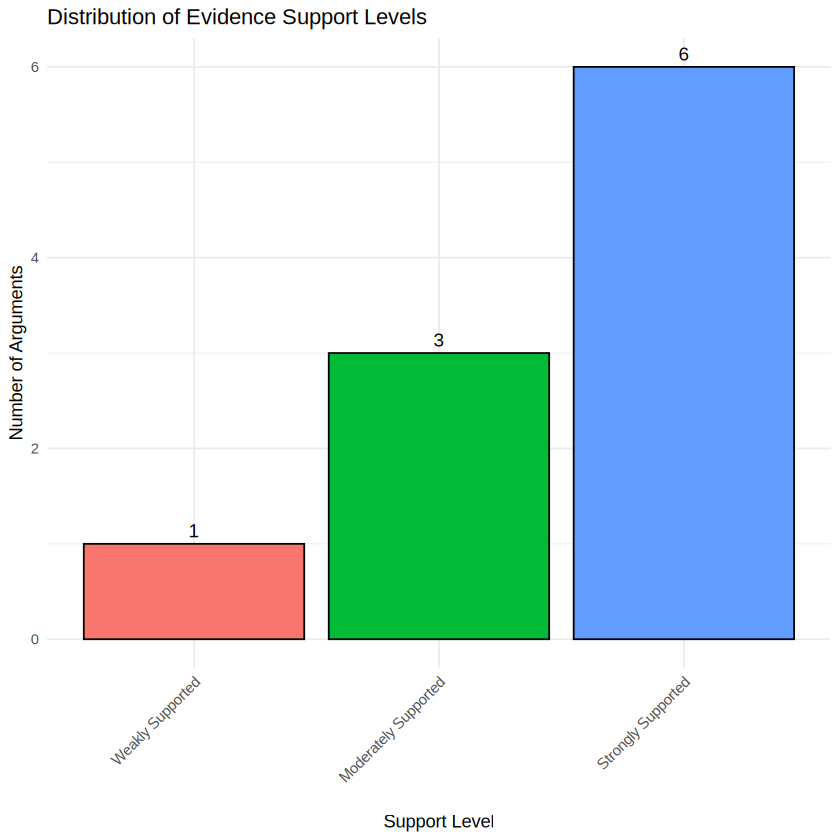

In [62]:
if (!require("ggplot2")) install.packages("ggplot2")
library(ggplot2)

strength_counts <- as.data.frame(table(knowledge_base$Support_Level))
colnames(strength_counts) <- c("Support_Level", "Count")

strength_counts$Support_Level <- factor(strength_counts$Support_Level,
                                       levels = c("No Support", "Weakly Supported", "Moderately Supported", "Strongly Supported"))

ggplot(strength_counts, aes(x = Support_Level, y = Count, fill = Support_Level)) +
  geom_bar(stat = "identity", color = "black") +
  geom_text(aes(label = Count), vjust = -0.5, size = 4) +
  labs(title = "Distribution of Evidence Support Levels",
       x = "Support Level",
       y = "Number of Arguments") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none")

### Formatted Final Debate Report

In [63]:
generate_debate_report <- function(kb) {
  cat("--- AI in Education Debate Report ---\n\n")

  positions <- unique(kb$Position)
  for (pos in positions) {
    cat(sprintf("## Position: %s\n\n", pos))
    subset_kb <- subset(kb, Position == pos)

    topics <- unique(subset_kb$Topic)
    for (topic in topics) {
      cat(sprintf("### Topic: %s\n", topic))
      topic_arguments <- subset(subset_kb, Topic == topic)

      for (i in 1:nrow(topic_arguments)) {
        arg <- topic_arguments[i, ]
        cat(sprintf("  - **Argument ID:** %s\n", arg$Argument_ID))
        cat(sprintf("    **Claim:** %s\n", arg$Claim))
        cat(sprintf("    **Evidence Type:** %s\n", arg$Evidence_Type))
        cat(sprintf("    **Evidence Strength:** %s (Score: %d)\n", arg$Strength, arg$Evidence_score))
        cat(sprintf("    **Support Level:** %s\n\n", arg$Support_Level))
      }
    }
  }
  cat("--- End of Report ---\n")
}

generate_debate_report(knowledge_base)

--- AI in Education Debate Report ---

## Position: For

### Topic: Learning
  - **Argument ID:** A001
    **Claim:** AI can provide students with immediate learning support.
    **Evidence Type:** Research
    **Evidence Strength:** Strong (Score: 3)
    **Support Level:** Strongly Supported

### Topic: Productivity
  - **Argument ID:** A002
    **Claim:** AI can help students complete routine academic tasks more efficiently.
    **Evidence Type:** Research
    **Evidence Strength:** Moderate (Score: 2)
    **Support Level:** Moderately Supported

### Topic: AI Literacy
  - **Argument ID:** A003
    **Claim:** Allowing AI use can help students develop AI literacy.
    **Evidence Type:** Policy
    **Evidence Strength:** Strong (Score: 3)
    **Support Level:** Strongly Supported

### Topic: Personalization
  - **Argument ID:** A007
    **Claim:** AI can personalize learning experiences for diverse student needs.
    **Evidence Type:** Research
    **Evidence Strength:** Strong (Score: